# Green's function renormalization algorithm

The surface/bulk spectral functions of a semi-infinite system (previous notebooks) are obtained
from `greentk.rg.green_renormalization`: a real-space renormalization (decimation) iteration --
Sancho, Lopez Sancho & Rubio, J. Phys. F: Met. Phys. 15, 851 (1985) -- that repeatedly
"decimates" pairs of unit cells, doubling the effective range of a semi-infinite chain's hopping at
each step, until the surface/bulk self-energies converge. It needs only a single unit cell's
intracell (`intra`) and intercell (`inter`) hopping matrices and directly returns the bulk and
surface Green's functions -- no diagonalization of the (infinite) chain is ever performed. Below,
the resulting bulk DOS of a plain 1D chain is checked against the exact analytic tight-binding DOS.

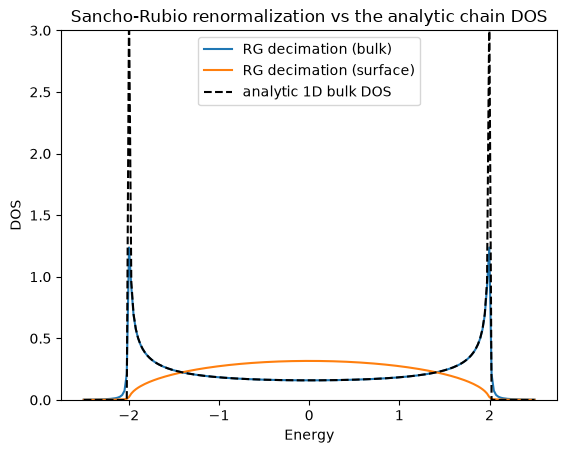

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.greentk.rg import green_renormalization

g = geometry.chain()
h = g.get_hamiltonian(has_spin=False)
intra,inter = h.intra,h.inter

energies = np.linspace(-2.5,2.5,200)
dos_bulk,dos_surf = [],[]
for e in energies:
    gb,gs = green_renormalization(intra,inter,energy=e,delta=1e-2)
    dos_bulk.append(-np.trace(gb).imag/np.pi)
    dos_surf.append(-np.trace(gs).imag/np.pi)

t = 1.0 # hopping amplitude of geometry.chain()
analytic = np.array([1./(np.pi*np.sqrt(4*t**2-e**2)) if abs(e)<2*t else 0.0 for e in energies])

plt.plot(energies,dos_bulk,label="RG decimation (bulk)")
plt.plot(energies,dos_surf,label="RG decimation (surface)")
plt.plot(energies,analytic,"k--",label="analytic 1D bulk DOS")
plt.ylim(0,3)
plt.xlabel("Energy") ; plt.ylabel("DOS")
plt.legend()
plt.title("Sancho-Rubio renormalization vs the analytic chain DOS")
plt.show()